In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_handling.dataset import ECGDataset
import torch
from src.model import (
    CNNAutoencoder,
    TransformerAutoencoder,
    patch_proj,
    patch_proj_inv,
    MAE1D,
    ViT1DEncoder
)
from torch.utils.data import DataLoader

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd()))
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

In [23]:
preprocessed_data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz")
json_split_path = os.path.join(DATA_DIR, 'input', 'experiment', 'leads_MLII_V1_tst0.25_rd42.json')

# Double channel (MLII + V1)
ds2 = ECGDataset(preprocessed_data_dir, window_size=1024, stride=512,  json_file_path=json_split_path, mode="sliding", split='val')


Loading data for 8 patients from 'val' split...


In [24]:
model_path1 = os.path.join(DATA_DIR, 'output','mae_test.pth', 'mae_epoch1.pt')
model_path2 = os.path.join(DATA_DIR, 'output','mae_test.pth', 'mae_epoch25.pt')

# autoencoder = TransformerAutoencoder(in_channels=2, emb_size=32, patch_size=10, num_layers=1, nhead=2)
# autoencoder = CNNAutoencoder(in_channels=2, latent_dim=64)
# autoencoder_random = CNNAutoencoder(in_channels=2, latent_dim=64)
# encoder = ViT1DEncoder(signal_length=1024, patch_size=16, in_channels=2,
#                            embed_dim=64, depth=4, num_heads=4, mlp_ratio=2.0,
#                            dropout=0.1, max_rel_len=1024, use_cls_token=False)

# mae = MAE1D(encoder=encoder, decoder_embed_dim=64, decoder_depth=2, mask_ratio=0.75)

model1 = TransformerAutoencoder(in_channels=2, emb_size=128, patch_size=32, num_layers=2, nhead=4)
model2 = TransformerAutoencoder(in_channels=2, emb_size=128, patch_size=32, num_layers=2, nhead=4)


model_saved = torch.load(model_path1)
model1.load_state_dict(model_saved["model_state"])
model1.eval()

model_saved = torch.load(model_path2)
model2.load_state_dict(model_saved["model_state"])
model2.eval()

TransformerAutoencoder(
  (encoder_embed): PatchEmbedding1D(
    (proj): Conv1d(2, 128, kernel_size=(32,), stride=(32,))
    (pos_emb_generator): PositionalEncoding(
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder_pos_embed): LearnedPositionalEmbedding()
  (decoder): Transfo

In [25]:
ssl_loader = DataLoader(ds2, batch_size=32)
signals, labels = next(iter(ssl_loader))  # shape: [B, C, T]
with torch.no_grad():
    recon1 = model1(labels)  # shape: [B, C, T]
    recon2 = model2(labels)  # shape: [B, C, T]

In [26]:
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def visualize_mae_reconstruction(model, x, leads=['MLII', 'V1'], mask_ratio=0.4, sample_idx=0):
    """
    Visualize MAE reconstruction for a 1D signal.

    Args:
        model: trained TransformerAutoencoder
        x: input tensor [B, C, T]
        mask_ratio: fraction of patches to mask (for deterministic viz)
        sample_idx: which batch element to visualize
    """
    model.eval()
    device = next(model.parameters()).device
    x = x.to(device)

    # forward pass
    out = model(x, mask_ratio=mask_ratio)
    recon_patches = out['recon']                # [B, num_patches, C*P]
    ids_mask, ids_keep = out['mask']
    B, C, T = x.shape
    patch_size = model.patch_size

    # reconstruct full 1D signal from predicted patches
    recon_signal = patch_proj_inv(recon_patches, C, patch_size)[sample_idx].cpu().squeeze()

    # original signal
    true_signal = x[sample_idx].cpu().squeeze()

    # convert mask indices to actual time coordinates for shading
    num_patches = recon_patches.shape[1]
    masked_patches = ids_mask[sample_idx].cpu().numpy()
    masked_regions = [(i * patch_size, (i+1) * patch_size) for i in masked_patches]

    # --- plot
    fig, axes = plt.subplots(C, 1, figsize=(12, 2*C), sharex=True)
    if C == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(true_signal[i], label="Original", color='black', linewidth=2, alpha=0.6)
        ax.plot(recon_signal[i], label="Reconstruction", color='tab:red', alpha=0.8)
        # highlight masked regions
        for start, end in masked_regions:
            ax.axvspan(start, end, color='gray', alpha=0.2)
        if leads:
            ax.set_ylabel(leads[i])
            ax.set_xlabel("Time steps")
        ax.grid(True, linestyle="--", alpha=0.5)

    # plt.
    # plt.plot(recon_signal, label="Reconstruction", color='tab:red', alpha=0.8)

    

    # plt.legend()
    fig.suptitle(f"MAE 1D Reconstruction (mask_ratio={mask_ratio:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.show()


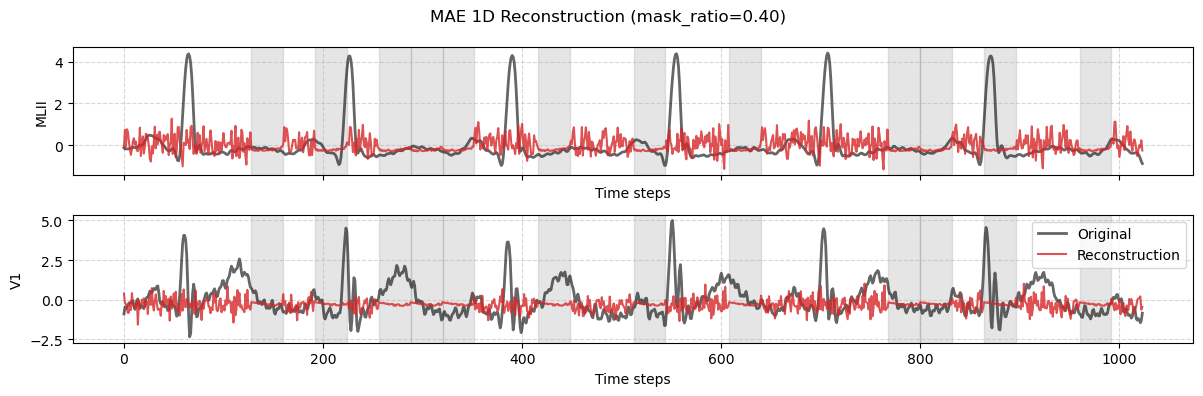

In [27]:
visualize_mae_reconstruction(model2, labels, mask_ratio=0.4, sample_idx=0)
